### Import libraries and set processing device

In [1]:
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# Check for GPU (CUDA for Nvidia, MPS for Mac) or fallback to CPU
device: torch.device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Libraries imported. Code will run on: {device}")

Libraries imported. Code will run on: cpu


### Create the custom "Wide Image" dataset

This cell downloads MNIST and transforms it from single digit images ($28 \times 28$) into sequences of 5 concatenated digits ($28 \times 140$).

In [2]:
DATA_PATH: str = "./mnist_data"
BATCH_SIZE: int = 64
ZIP_CODE_LENGTH: int = 5  # We will stitch 5 digits together

# Standard MNIST transform (Normalize to -1 to 1 range)
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

# Download base MNIST data
print("Checking for MNIST data...")
mnist_train = datasets.MNIST(
    root=DATA_PATH, train=True, transform=transform, download=True
)
mnist_test = datasets.MNIST(
    root=DATA_PATH, train=False, transform=transform, download=True
)


class ZipCodeDataset(Dataset):
    def __init__(
        self,
        mnist_dataset: datasets.MNIST,
        zip_length: int = ZIP_CODE_LENGTH,
    ) -> None:
        self.mnist_dataset = mnist_dataset
        self.zip_length = zip_length
        self.total_samples = len(mnist_dataset) // zip_length

    def __len__(self) -> int:
        return self.total_samples

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        images: list[torch.Tensor] = []
        labels: list[int] = []

        # Grab 'zip_length' consecutive images
        start_idx = idx * self.zip_length
        for i in range(self.zip_length):
            img, label = self.mnist_dataset[start_idx + i]
            images.append(img)
            labels.append(label)

        # Concatenate horizontally: (1, 28, 28) * 5 -> (1, 28, 140)
        zip_image = torch.cat(images, dim=2)
        zip_labels = torch.tensor(labels, dtype=torch.long)
        return zip_image, zip_labels


# Create DataLoaders
train_dataset = ZipCodeDataset(mnist_train)
test_dataset = ZipCodeDataset(mnist_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(
    f"Wide Dataset Ready. Input shape: (1, 28, 140). Training samples: {len(train_dataset)}"
)

Checking for MNIST data...
Wide Dataset Ready. Input shape: (1, 28, 140). Training samples: 12000


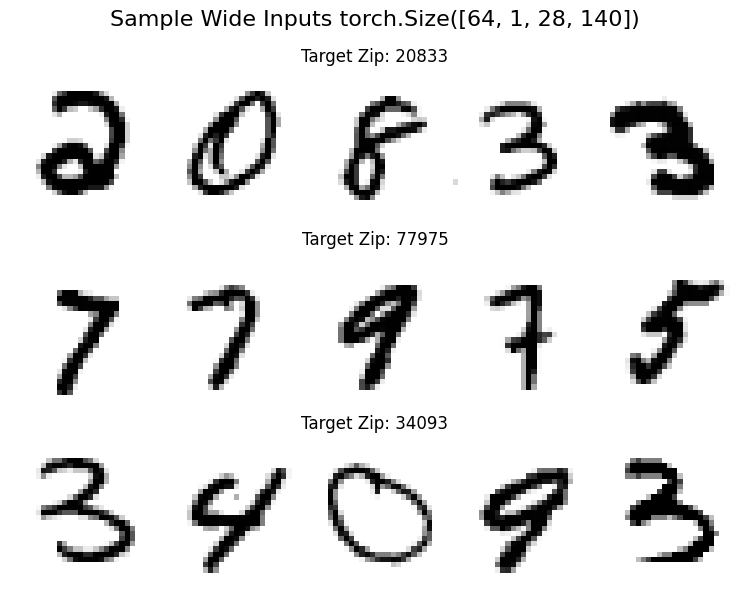

In [3]:
def show_wide_batch(loader: DataLoader) -> None:
    images, labels = next(iter(loader))

    plt.figure(figsize=(10, 6))
    plt.suptitle(f"Sample Wide Inputs {images.shape}", fontsize=16)

    for i in range(3):  # Show top 3 rows
        plt.subplot(3, 1, i + 1)
        # Squeeze removes color channel: (1, 28, 140) -> (28, 140)
        plt.imshow(images[i].squeeze(), cmap="gray_r")

        # Format label list for display
        label_str = "".join([str(l.item()) for l in labels[i]])
        plt.title(f"Target Zip: {label_str}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_wide_batch(train_loader)

### Define the multi-output CNN architecture

This model is adapted for wider inputs. The final layer outputs 50 numbers, which we reshape into a $(5 \times 10)$ grid (5 digits, 10 probabilities each).

In [4]:
class WideZipNet(nn.Module):
    def __init__(self) -> None:
        super(WideZipNet, self).__init__()

        # Layer 1: Input (1, 28, 140) -> Pool to (16, 14, 70)
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Layer 2: Input (16, 14, 70) -> Pool to (32, 7, 35)
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Fully Connected Layer
        # Flattened size = 32 channels * 7 height * 35 width = 7840 inputs
        # Output size = 5 digits * 10 classes (0-9) = 50 outputs
        self.fc = nn.Linear(32 * 7 * 35, 5 * 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.layer1(x)
        out = self.layer2(out)

        # Flatten
        out = out.reshape(out.size(0), -1)

        # Predict 50 values
        out = self.fc(out)

        # We split the 50 outputs into 5 groups of 10
        out = out.view(-1, 5, 10)
        return out


model = WideZipNet().to(device)
print("WideZipNet model created.")

WideZipNet model created.


### Configure training and saving

In [5]:
LEARNING_RATE: float = 0.001
EPOCHS: int = 7
MODEL_SAVE_PATH: str = "./exports/wide_zip_net.pth"

os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Configuration set. Model will be saved to: {MODEL_SAVE_PATH}")

Configuration set. Model will be saved to: ./exports/wide_zip_net.pth


### Train/load the model

In [6]:
def train_wide_network(
    num_epochs: int,
    model: nn.Module,
    loader: DataLoader,
) -> None:
    model.train()
    print(f"Starting training on {str(device).upper()}...")

    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            # We must sum the loss for each of the 5 digit positions
            loss = 0
            for digit_idx in range(ZIP_CODE_LENGTH):
                # Compare the predicted label for digit i with the actual label for digit i.
                loss += criterion(outputs[:, digit_idx, :], labels[:, digit_idx])

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if (i + 1) % 100 == 0:
                print(
                    f"Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}], Loss: {loss.item():.4f}"
                )

    torch.save(model.state_dict(), MODEL_SAVE_PATH)
    print("Training finished.")


if os.path.exists(MODEL_SAVE_PATH):
    ans = input(f"Found saved model at {MODEL_SAVE_PATH!r}. Load it (y/N)? ")
    if ans.lower() == "y":
        model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
        print("Model loaded successfully!")
    else:
        print("Retraining model...")
        train_wide_network(EPOCHS, model, train_loader)
else:
    print("No saved model found. Training from scratch...")
    train_wide_network(EPOCHS, model, train_loader)

Found saved model at './exports/wide_zip_net.pth'. Load it (y/N)?  n


Retraining model...
Starting training on CPU...
Epoch [1/7], Step [100], Loss: 2.8297
Epoch [2/7], Step [100], Loss: 0.8016
Epoch [3/7], Step [100], Loss: 0.4437
Epoch [4/7], Step [100], Loss: 0.2426
Epoch [5/7], Step [100], Loss: 0.1044
Epoch [6/7], Step [100], Loss: 0.1299
Epoch [7/7], Step [100], Loss: 0.0428
Training finished.


### Visualize results on test data

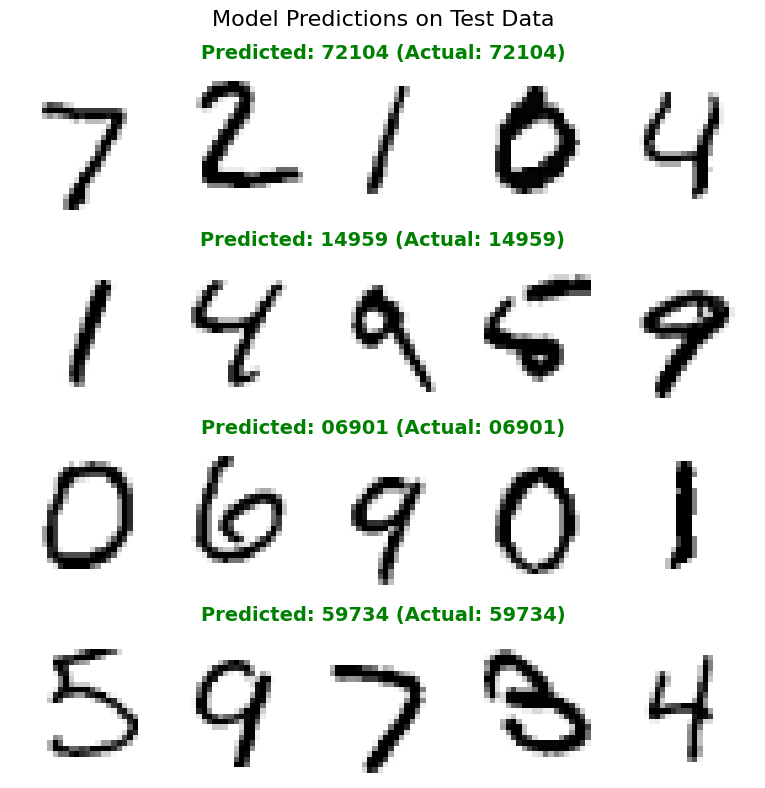

In [10]:
def visualize_wide_result(model: nn.Module, loader: DataLoader) -> None:
    model.eval()

    # Get one batch of wide images
    images, labels = next(iter(loader))
    images = images.to(device)

    # Predict
    with torch.no_grad():
        outputs = model(images)
        # Get indices of max probability for the last dimension (dim 2)
        _, predictions = torch.max(outputs, 2)

    # Move to CPU for plotting
    images = images.cpu()
    predictions = predictions.cpu()
    labels = labels.cpu()

    # Plot top 4 results
    plt.figure(figsize=(12, 8))
    plt.suptitle("Model Predictions on Test Data", fontsize=16)

    for i in range(4):
        ax = plt.subplot(4, 1, i + 1)

        pred_str = "".join([str(d.item()) for d in predictions[i]])
        true_str = "".join([str(l.item()) for l in labels[i]])

        ax.imshow(images[i].squeeze(), cmap="gray_r")
        ax.set_title(
            f"Predicted: {pred_str} (Actual: {true_str})",
            fontsize=14,
            color="green" if pred_str == true_str else "red",
            weight="bold",
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_wide_result(model, test_loader)